In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import re
import networkx as nx
from itertools import combinations

### conversion to pd df

In [2]:
df_users = pd.read_csv('DATA3/users.csv')
print(df_users.shape)
df_users.head(2)

(3466, 5)


,id,name,address,phone,email
0,47856,Tammie Mayer,"Apt. 371 1875 Gusikowski Stravenue, Moenland, ...",163.212.2656,maire.larson@runolfsdottir-mclaughlin.example
1,49394,Evia Yost,"22610 Mildred Green, Pagacbury, AZ 19393-2103",778.926.6707,byron@johnston.test


In [3]:
df_orders = pd.read_parquet('DATA3/orders.parquet', engine='pyarrow')
print(df_orders.shape)
df_orders.head(2)

(8933, 7)


,id,user_id,book_id,quantity,unit_price,timestamp,shipping
0,80941,47864,21550,1,67.0 €,2025-01-11 09:50:11 PM,
1,81245,47864,22052,2,EUR26.99,2024-03-27T07:46:55.055,


In [4]:
with open('DATA3/books.yaml', 'r') as f:
    books_data = yaml.safe_load(f)

df_books = pd.DataFrame(books_data)
print(df_books.shape)
df_books.columns = df_books.columns.str.lstrip(':')

(762, 6)


In [5]:
df_books.head(2)

,id,title,author,genre,publisher,year
0,21778,Call of Duty: World at War,Elmer Parker,Mythopoeia,Orion Books,2003
1,21374,WarioWare: Touched!,Ms. Kami Prosacco,Mythology,St. Martin's Press,1951


### nulls in data

In [6]:
users_total_nulls = df_users.isnull().sum().sum()
print(f"Total users missing values: {users_total_nulls}")

Total users missing values: 122


In [7]:
orders_total_nulls = df_orders.isnull().sum().sum()
print(f"Total orders missing values: {orders_total_nulls}")

Total orders missing values: 2212


In [8]:
books_total_nulls = df_books.isnull().sum().sum()
print(f"Total books missing values: {books_total_nulls}")

Total books missing values: 5


In [9]:
users_nulls = df_users.isnull().sum()
print("df_users: null columns:")
print(users_nulls[users_nulls > 0], "\n")

orders_nulls = df_orders.isnull().sum()
print("df_orders: null columns:")
print(orders_nulls[orders_nulls > 0], "\n")

books_nulls = df_books.isnull().sum()
print("df_books: null columns:")
print(books_nulls[books_nulls > 0], "\n")

df_users: null columns:
address    122
dtype: int64 

df_orders: null columns:
shipping    2212
dtype: int64 

df_books: null columns:
publisher    3
year         2
dtype: int64 



### feature processing & engineering

##### money

In [10]:
df_orders["unit_price"].head(2)

0      67.0 €
1    EUR26.99
Name: unit_price, dtype: str

In [11]:
def convert_to_usd(value):
    clean_val = re.sub(r'[¢]', '.', str(value))
    
    amount_match = re.search(r'(\d+\.?\d*)', clean_val)
    if not amount_match:
        return 0.0
    
    amount = float(amount_match.group(1))
    
    if any(x in clean_val.upper() for x in ['€', 'EUR']):
        amount *= 1.2
        
    return round(amount, 2)

In [12]:
df_orders['unit_price'] = df_orders['unit_price'].apply(convert_to_usd)
df_orders['unit_price'].head(2)

0    80.40
1    32.39
Name: unit_price, dtype: float64

In [13]:
df_orders['paid_price'] = df_orders['quantity'] * df_orders['unit_price']

In [14]:
df_orders.head(2)

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,paid_price
0,80941,47864,21550,1,80.40,2025-01-11 09:50:11 PM,,80.40
1,81245,47864,22052,2,32.39,2024-03-27T07:46:55.055,,64.78


##### dates

In [15]:
df_orders['timestamp'].head()

0      2025-01-11 09:50:11 PM
1     2024-03-27T07:46:55.055
2    11:17:51 PM, 29-JUN-2025
3              09:29;11/06/24
4      2024-09-16;03:05:39 pm
Name: timestamp, dtype: str

In [16]:
clean_timestamps = (
    df_orders['timestamp']
    .str.replace(r'([AP])\.M\.', r'\1M', regex=True, case=False)
    .str.replace(r'[,;]', ' ', regex=True)
)

df_orders['date_extracted'] = pd.to_datetime(clean_timestamps, format='mixed').dt.date

In [17]:
df_orders.head()

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,paid_price,date_extracted
0,80941,47864,21550,1,80.40,2025-01-11 09:50:11 PM,,80.40,2025-01-11
1,81245,47864,22052,2,32.39,2024-03-27T07:46:55.055,,64.78,2024-03-27
2,78477,48918,21367,1,30.00,"11:17:51 PM, 29-JUN-2025",,30.00,2025-06-29
3,86303,48092,21724,1,18.00,09:29;11/06/24,NaN,18.00,2024-11-06
4,81990,48418,21441,1,24.99,2024-09-16;03:05:39 pm,NaN,24.99,2024-09-16


### metrics

#### money date metrics

In [18]:
daily_rev = df_orders.groupby('date_extracted')['paid_price'].sum().reset_index()
daily_rev = daily_rev.sort_values('date_extracted') # Ensure chronological order

print("daily revenue:")
daily_rev.head(2)

daily revenue:


,date_extracted,paid_price
0,2024-01-04,141.17
1,2024-01-06,48.00


In [19]:
top_5_days = daily_rev.sort_values(by='paid_price', ascending=False).head(5)
print("top 5 days with highest revenue:")
print(top_5_days)

top 5 days with highest revenue:
    date_extracted  paid_price
295     2024-11-16     3688.20
371     2025-01-31     3341.99
274     2024-10-26     3127.92
291     2024-11-12     3034.54
280     2024-11-01     2954.03


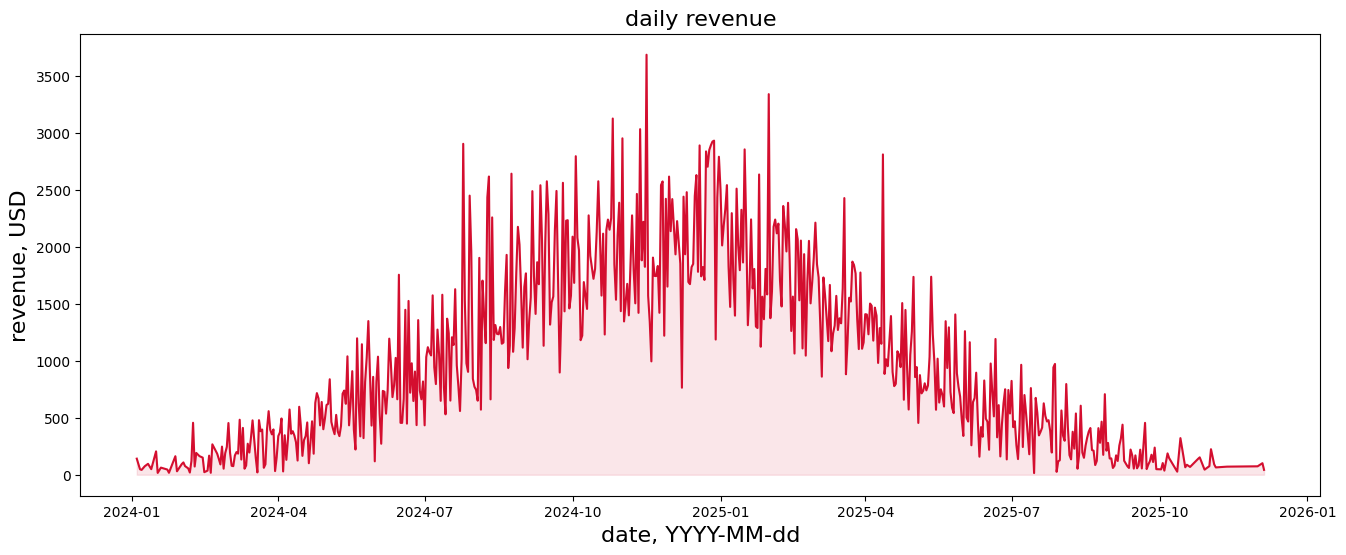

In [20]:
plt.figure(figsize=(16, 6))
plt.plot(daily_rev['date_extracted'], daily_rev['paid_price'], color="#D40E2F")

plt.title('daily revenue', fontsize=16)
plt.xlabel('date, YYYY-MM-dd', fontsize=16)
plt.ylabel('revenue, USD', fontsize=16)
plt.fill_between(daily_rev['date_extracted'], daily_rev['paid_price'], 
                 color="#D40E2F", 
                 alpha=0.1)

plt.show()

#### author metrics

In [21]:
num_unique_author_strings = df_books['author'].nunique()

print(f"Number of unique author entries: {num_unique_author_strings}")

Number of unique author entries: 325


In [22]:
def author_setting(author_str):
    if pd.isna(author_str):
        return ""
    authors = sorted([a.strip().lower() for a in str(author_str).split(',')])
    return ", ".join(authors)

In [23]:
df_books['author_set'] = df_books['author'].apply(author_setting)

In [24]:
print(f"Number of unique sets of authors: {df_books['author_set'].nunique()}")

Number of unique sets of authors: 268


#### unique users

In [25]:
fields = ['name', 'address', 'phone', 'email']

G = nx.Graph()
G.add_nodes_from(df_users['id'])

for combo in combinations(fields, 3):
    groups = df_users.groupby(list(combo))
    for _, group in groups:
        if len(group) > 1:
            uids = group['id'].tolist()
            for i in range(len(uids)):
                for j in range(i + 1, len(uids)):
                    G.add_edge(uids[i], uids[j])

unique_user_clusters = list(nx.connected_components(G))
print(f"Number of real unique users: {len(unique_user_clusters)}")

Number of real unique users: 3290


#### most popular author/set

In [26]:
df_sales_authors = df_orders.merge(df_books[['id', 'author_set']], left_on='book_id', right_on='id')

popularity = df_sales_authors.groupby('author_set')['quantity'].sum().sort_values(ascending=False)

most_popular = popularity.idxmax()
sales_count = popularity.max()

In [27]:
print(f"Most popular author(s): {most_popular}")
print(f"Total books sold: {sales_count}")

Most popular author(s): coy streich, keeley hand, lela emard
Total books sold: 159


#### top spending customers

In [28]:
user_to_cluster = {}
for idx, cluster in enumerate(unique_user_clusters):
    for uid in cluster:
        user_to_cluster[uid] = idx

df_orders['cluster_id'] = df_orders['user_id'].map(user_to_cluster)

spending_per_user = df_orders.groupby('cluster_id')['paid_price'].sum()
top_cluster_idx = spending_per_user.idxmax()
total_spent = spending_per_user.max()

top_customer_ids = list(unique_user_clusters[top_cluster_idx])

top_customer_names = df_users[df_users['id'].isin(top_customer_ids)]['name'].unique().tolist()

In [29]:
print(f"Top customer names: {top_customer_names}")
print(f"Top customer total spending: ${total_spent:.2f}")
print(f"Original user_id values for this customer: {top_customer_ids}")

Top customer names: ['Tony Sawayn', 'Long Bogisich IV']
Top customer total spending: $1207.48
Original user_id values for this customer: [50963, 49715]


In [30]:
top_customer_rows = df_users[df_users['id'].isin(top_customer_ids)]
top_customer_rows.head()

,id,name,address,phone,email
527,49715,Tony Sawayn,"Apt. 755 91534 Edgar Dale, Gradyland, AL 98124",(526) 708-1955,robby@padberg.example
3063,50963,Long Bogisich IV,"Apt. 755 91534 Edgar Dale, Gradyland, AL 98124",(526) 708-1955,robby@padberg.example
